In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
#from keras.layers.core import Dense,Activation,Dropout
#from keras.layers import Dense, Activation, Dropout
#from keras.datasets import mnist
#from keras.utils.np_utils import to_categorical
#from keras.wrappers.scikit_learn import KerasClassifier
#from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.datasets import mnist
from keras.utils import to_categorical
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier


In [9]:
!pip install scikeras

In [2]:
#Digit MNIST dataset
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

In [3]:
y_train_digit[13]

np.uint8(6)

In [4]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

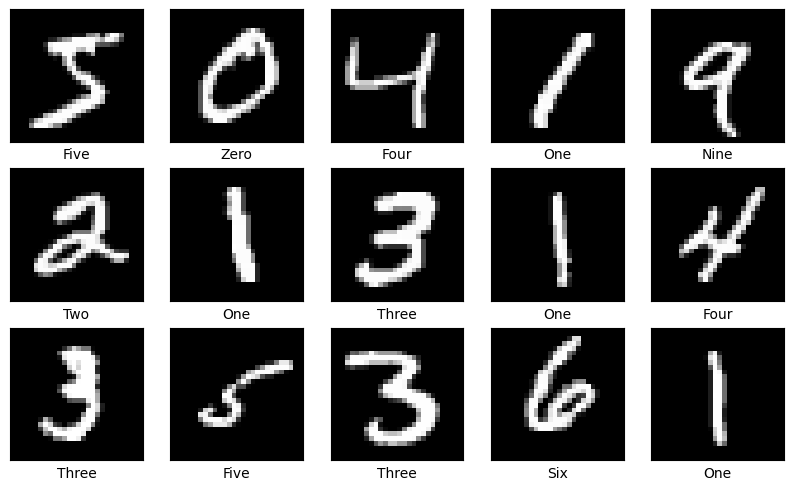

In [5]:
#Visually plot the digits
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])

plt.show()

In [6]:
X_train_digit.shape
X_test_digit.shape

(10000, 28, 28)

In [7]:
#Preprocessing the input - Converting 3d to 2d
X_train_digit = X_train_digit.reshape(60000, 784) #minst data set array 28 X 28 -->784
X_test_digit = X_test_digit.reshape(10000, 784)

In [8]:
y_test_digit

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [9]:
y_test_digit.shape

(10000,)

In [10]:
#Neural networks don’t understand categories directly.  They need numeric vectors to represent classes.
y_train_digit = to_categorical(y_train_digit, num_classes=10)

y_test_digit = to_categorical(y_test_digit, num_classes=10)

In [11]:
y_test_digit[8]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [12]:
type(y_test_digit)

numpy.ndarray

In [13]:
#Creating base neural network. This code defines a feed‑forward neural network (multilayer perceptron) using Keras’ Sequential API
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='sigmoid'),
])

C:\Users\DELL\anaconda3\envs\ml_ai\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#Compiling the model
#Compiling the model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ['accuracy'])

In [16]:
#history=model.fit(X_train_digit, y_train_digit, batch_size=10, epochs=10, validation_data=(X_test_digit, y_test_digit))
history=model.fit(X_train_digit, y_train_digit, batch_size=100, epochs=10,validation_data=(X_test_digit, y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7626 - loss: 1.3963 - val_accuracy: 0.8649 - val_loss: 0.3985
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8830 - loss: 0.2600 - val_accuracy: 0.8851 - val_loss: 0.2378
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8976 - loss: 0.1778 - val_accuracy: 0.8842 - val_loss: 0.2071
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9230 - loss: 0.1478 - val_accuracy: 0.9029 - val_loss: 0.2022
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9266 - loss: 0.1217 - val_accuracy: 0.9222 - val_loss: 0.1764
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9361 - loss: 0.1034 - val_accuracy: 0.9276 - val_loss: 0.1734
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9299 - loss: 0.1025 - val_accuracy: 0.9135 - val_loss: 0.1516
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9260 - loss: 0.0863 - val_accuracy

In [17]:
test_loss_digit, test_acc_digit = model.evaluate(X_test_digit, y_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9071 - loss: 0.1588


In [18]:
print('Digit MNIST test accuracy:', round(test_acc_digit,4))

Digit MNIST test accuracy: 0.9071


In [19]:
#PRdicting the labels-Digit
y_predict = model.predict(X_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [21]:
#The process of convering vector array into normal 1 D array
#[0.01, 0.05, 0.02, 0.80, 0.03, 0.04, 0.02, 0.01, 0.01, 0.01] --> [0,0,0,1,0,0,0,0,0,0] which is nothing but 3
y_predicts = np.argmax(y_predict, axis=1) #Convert the matrix array inot 0 and 1s and then Finds the index of the maximum value along each row.
y_test_digit_eval = np.argmax(y_test_digit, axis=1)

In [22]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6])

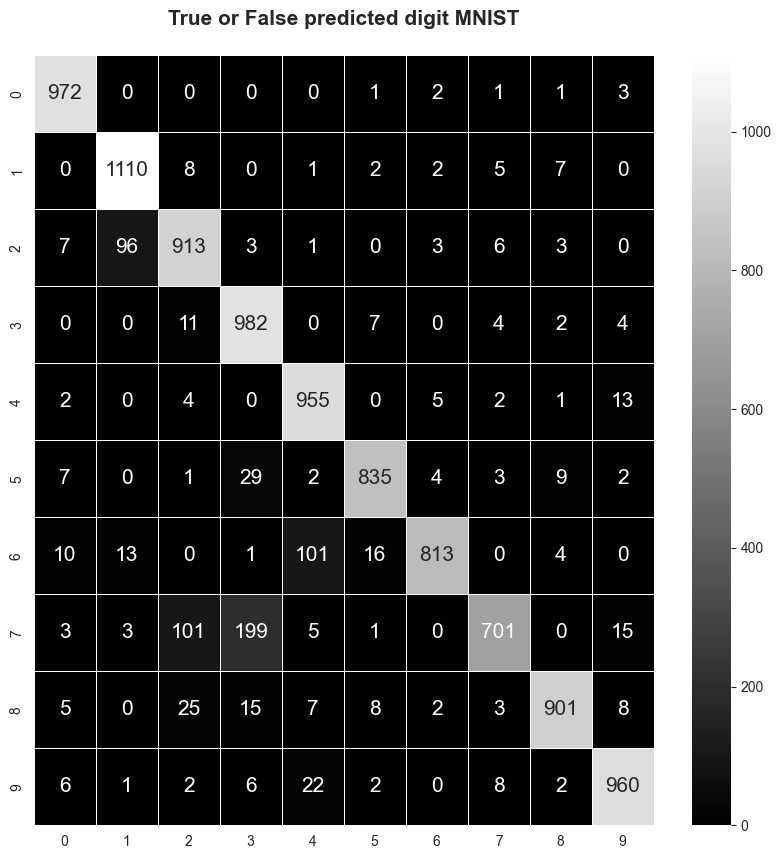

In [26]:
#Confusion Matrix
#Diagonal cells (top‑left to bottom‑right) = correct predictions
#Off‑diagonal cells = misclassifications (e.g., predicting “3” when the true digit was “5”).
#Darker cells = higher counts.
#972 → the model correctly predicted 972 images of digit “0” as “0”.
#1110 → the model correctly predicted 1110 images of digit “1” as “1”.
#983 → the model correctly predicted 983 images of digit “2” as “2”.
import matplotlib.pyplot as plt
con_mat = confusion_matrix(y_test_digit_eval, y_predicts)
sns.set_style("darkgrid")
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.91      0.98      0.94      1135
           2       0.86      0.88      0.87      1032
           3       0.80      0.97      0.87      1010
           4       0.87      0.97      0.92       982
           5       0.96      0.94      0.95       892
           6       0.98      0.85      0.91       958
           7       0.96      0.68      0.80      1028
           8       0.97      0.93      0.95       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



In [28]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


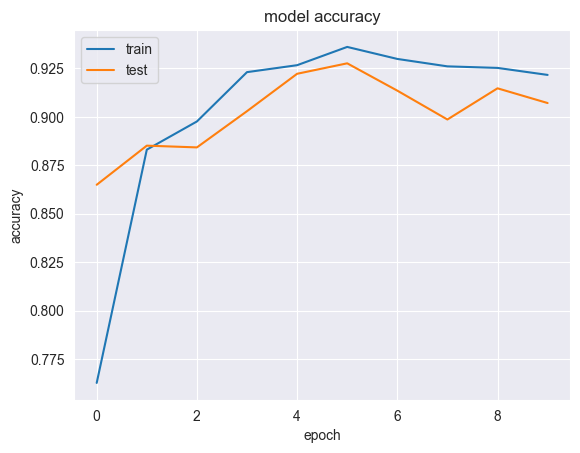

In [29]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


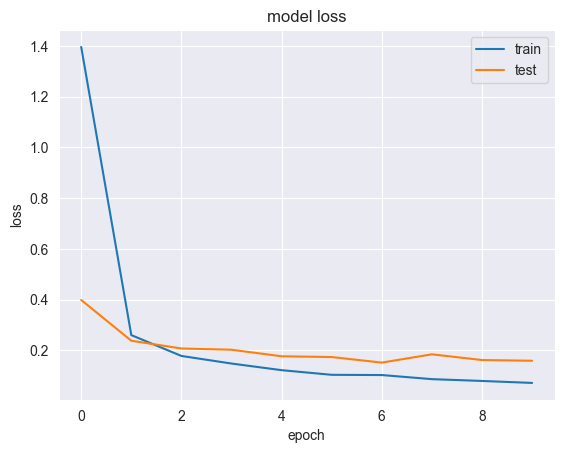

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [31]:
y_predict_single = model.predict(X_test_digit[[2]])
y_predicts_single = np.argmax(y_predict_single, axis=1)
y_predicts_single[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


np.int64(1)

In [33]:
y_predicts_single[0]

np.int64(1)

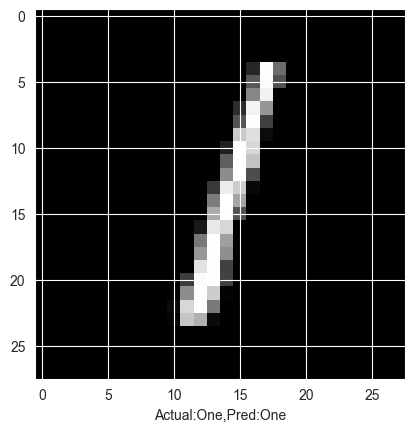

In [37]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
#plt.figure(figsize=(10,10))
plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_digit[2])],col_names[y_predicts_single[0]]))
plt.show()